In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pymc as pm
import arviz as az

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


Matplotlib is building the font cache; this may take a moment.


In [2]:
df = pd.read_csv("listings.csv")
df["new_price"] = df["price"].str.replace("$","", regex=False).str.replace(",","").astype(float) #price is a string, we need to conver it to a float to work with it
df.keys()

Index(['id', 'listing_url', 'scrape_id', 'last_scraped', 'source', 'name',
       'description', 'neighborhood_overview', 'picture_url', 'host_id',
       'host_url', 'host_profile_id', 'host_profile_url', 'host_name',
       'host_since', 'hosts_time_as_user_years', 'hosts_time_as_user_months',
       'hosts_time_as_host_years', 'hosts_time_as_host_months',
       'host_location', 'host_about', 'host_response_time',
       'host_response_rate', 'host_acceptance_rate', 'host_is_superhost',
       'host_thumbnail_url', 'host_picture_url', 'host_neighbourhood',
       'host_listings_count', 'host_total_listings_count',
       'host_verifications', 'host_has_profile_pic', 'host_identity_verified',
       'neighbourhood', 'neighbourhood_cleansed',
       'neighbourhood_group_cleansed', 'latitude', 'longitude',
       'property_type', 'room_type', 'accommodates', 'bathrooms',
       'bathrooms_text', 'bedrooms', 'beds', 'amenities', 'price',
       'price_quote_checkin_date', 'price_quote_c

In [3]:
#I thinks these are going to be some of the most useful to do our prediction
useful_columns = ["neighbourhood_cleansed", "new_price", "room_type", "accommodates", 'bathrooms', 
                 'bedrooms', 'beds', 'minimum_nights', 'number_of_reviews','latitude', 'longitude','availability_365',
                 'review_scores_rating']

(array([1.3099e+04, 1.6500e+02, 5.9000e+01, 2.3000e+01, 3.0000e+00,
        3.0000e+00, 1.0000e+00, 1.0000e+00, 0.0000e+00, 1.0000e+00]),
 array([3.500000e+00, 1.057372e+03, 2.111244e+03, 3.165116e+03,
        4.218988e+03, 5.272860e+03, 6.326732e+03, 7.380604e+03,
        8.434476e+03, 9.488348e+03, 1.054222e+04]),
 <BarContainer object of 10 artists>)

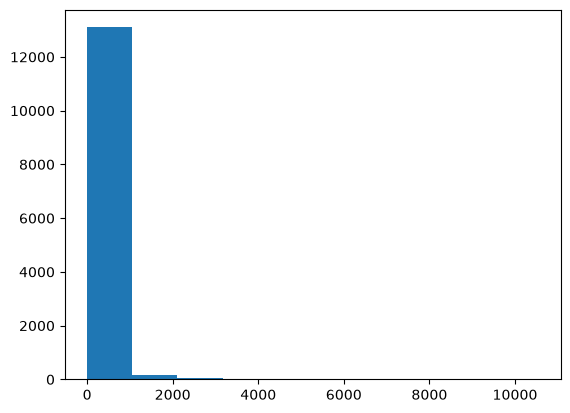

In [4]:
#now, lets see hot the pricing looks in a histogram
#I tried to look the price in a linear scale but this look awful
plt.hist(df["new_price"])


(array([6694., 4666., 1288.,  294.,   82.,   74.,   42.,   39.,   22.,
          18.]),
 array([   3.5 ,  178.95,  354.4 ,  529.85,  705.3 ,  880.75, 1056.2 ,
        1231.65, 1407.1 , 1582.55, 1758.  ]),
 <BarContainer object of 10 artists>)

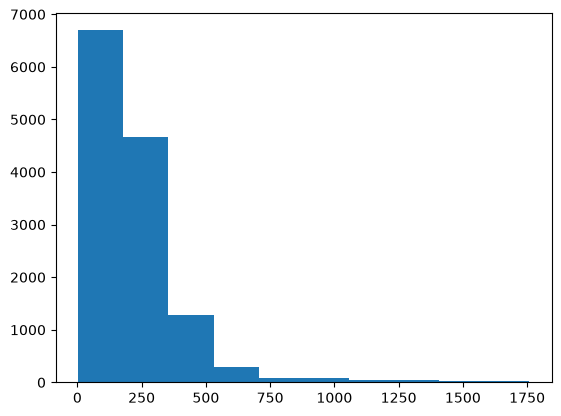

In [5]:
#plt.hist(df["new_price"], bins=10)
#There are some extrem values that I think are disorting the distribution lets drop them 1% should be enough also lets look for values that are greater since our client want prices for typical listings

df_percent = df[(df["new_price"] < df["new_price"].quantile(0.99))] #with this we get rid from off values that change the distribution

plt.hist(df_percent["new_price"])# it looks betternow!

In [6]:
#now, when I quickly saw the dataframe it contained several Nan values les drop them from every column
df_cleaned = df_percent.dropna(subset=useful_columns).copy()


Text(0, 0.5, 'counts')

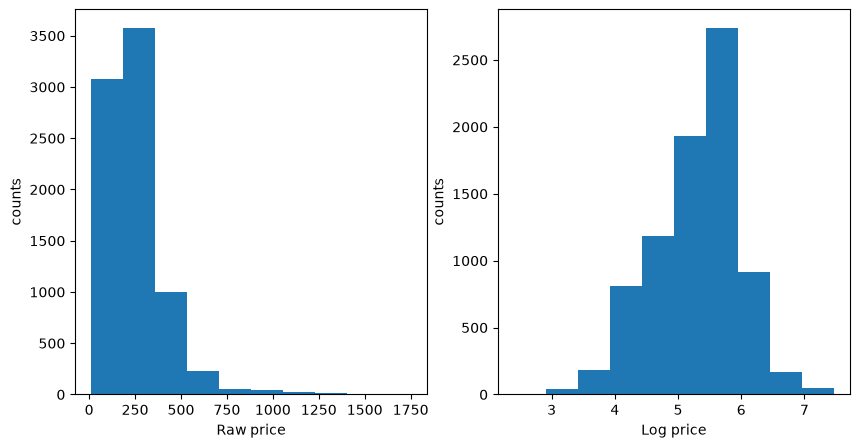

In [7]:
#Now, if we want to do a prediction for likelohood we need a normal distribution, transforming the price to log should do the trick

df_cleaned["log_price"] = np.log(df_cleaned["new_price"].copy())

#lets quickly compare the raw price vs the log one
fig = plt.figure(figsize = (10,5))
ax1 = fig.add_subplot(1,2,1)
ax2 = fig.add_subplot(1,2,2)
ax1.hist(df_cleaned["new_price"])
ax2.hist(df_cleaned["log_price"])

ax1.set_xlabel("Raw price")
ax2.set_xlabel("Log price")
ax1.set_ylabel("counts")
ax2.set_ylabel("counts")
#Perfect! Now we can use this for a model. In the future we can conver this into a python function if it need automation.


Text(0.5, 1.0, '')

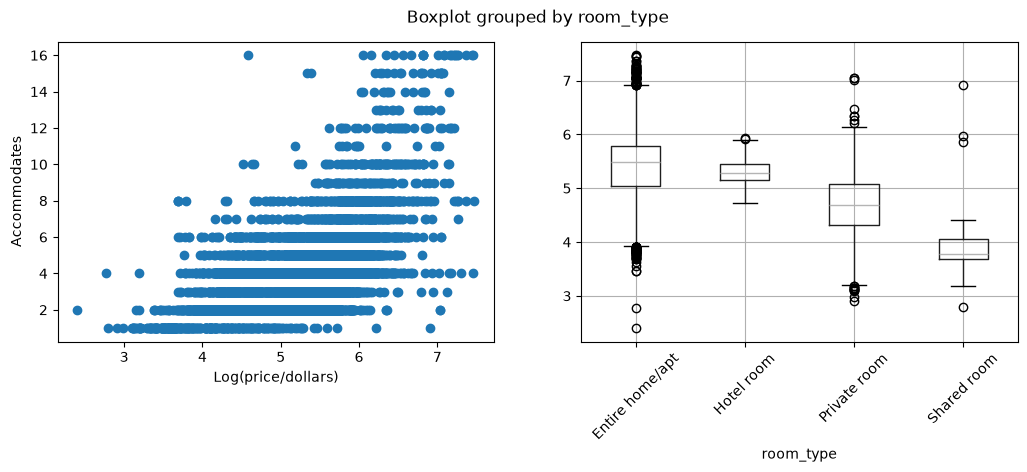

In [8]:
#Now lets see some quantities to make the feature selection for our model
#For example a good thing would be to see how price relates to accomodates, room_type or neighborhood.
fig = plt.figure(figsize= (12,4))
ax1 = fig.add_subplot(1,2,1)
ax2 = fig.add_subplot(1,2,2)


ax1.scatter(df_cleaned["log_price"], df_cleaned["accommodates"])
ax1.set_xlabel("Log(price/dollars)")
ax1.set_ylabel("Accommodates")


df_cleaned.boxplot(column="log_price", by='room_type',ax=ax2)
ax2.tick_params(axis='x', labelrotation=45)
ax2.set_title("")

#Lets print how many neighborhood do we have before doing a boxpplot



In [9]:
print(df_cleaned['neighbourhood_cleansed'].nunique());
#We have around 67! It think is better to use the mean as a descriptor and then plot it.

67


/var/folders/nq/wsmvmt1s13z6r5n3bf8588880000gn/T/ipykernel_28634/2836246563.py:5: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(data, vert=False, tick_labels=order)


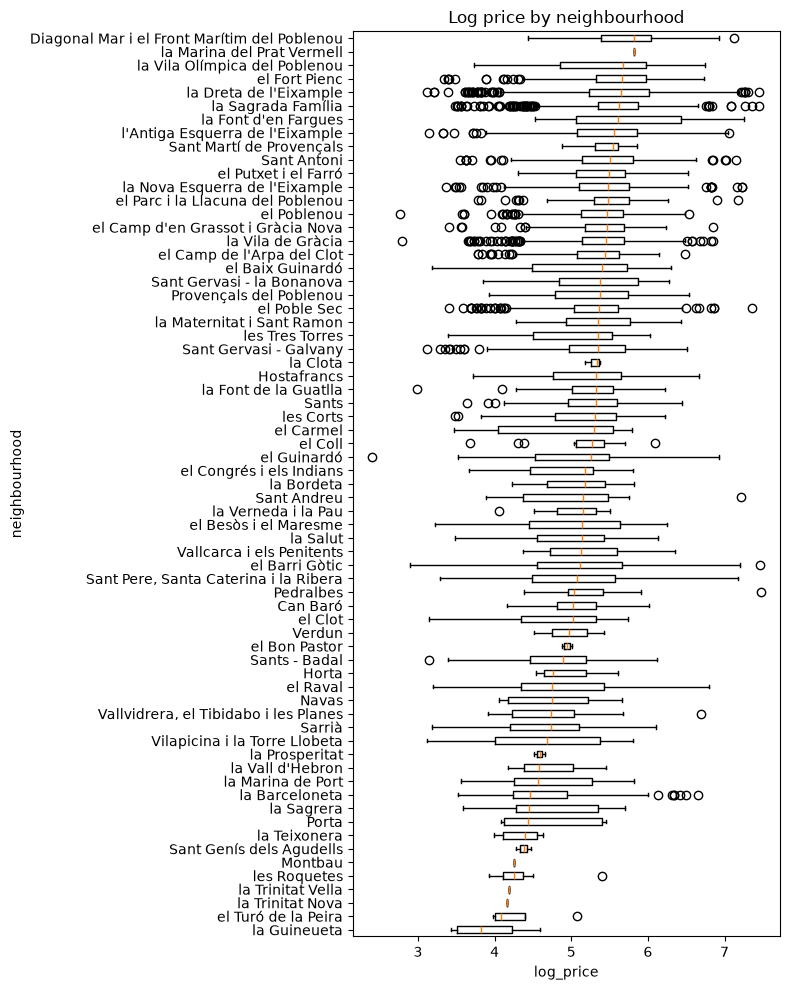

In [55]:
order = df_cleaned.groupby('neighbourhood_cleansed')['log_price'].median().sort_values().index
data = [df_cleaned.loc[df_cleaned['neighbourhood_cleansed'] == n, 'log_price'].values for n in order]
# 3. Plot — vert=False makes it horizontal
fig, ax = plt.subplots(figsize=(8, 10))
ax.boxplot(data, vert=False, tick_labels=order)
ax.set_xlabel('log_price')
ax.set_ylabel('neighbourhood')
ax.set_title('Log price by neighbourhood')
plt.tight_layout()
plt.show()
#There is a clear gradient in the plot, even after cleaning the 1% some touristic places as la sagrada familia are pricey!
#This is a real statistical trend.

Text(0, 0.5, 'Log price')

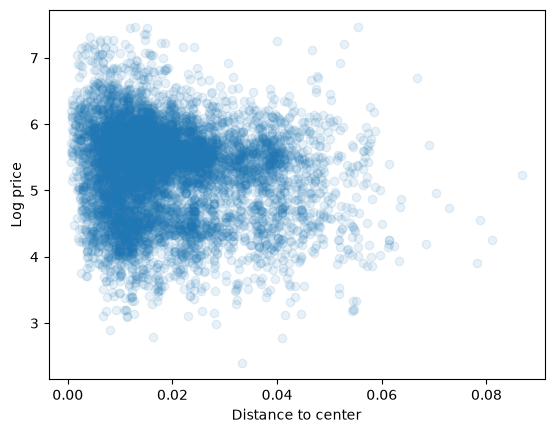

In [56]:
#Okay, now, lets see if we can find other trend with price. What about location? 
#For example lets use the city's center and see if there is a trend with price

#plaza cataluna is in:
center_lat, center_lon = 41.3874, 2.1686

#We calculate the distance to the center np.sqrt(x**2 + y**2)
df_cleaned["distance_center"] = np.sqrt((df_cleaned["longitude"] - center_lon)**2 + (df_cleaned["latitude"] - center_lat)**2)


plt.scatter(df_cleaned["distance_center"], df_cleaned["log_price"], alpha=0.1)
plt.xlabel("Distance to center")
plt.ylabel("Log price")

#There is a clear central cloud at around log price = 5-6
#But as the distance increase the price lowers, there is kind a mild trend but it is not near to what we already saw with location


In [57]:
#Now lets encode our categorical variables before doing the model
#lets starts with room_type with one-hot encoding.

df_cleaned["room_idx"] = df_cleaned["room_type"].astype("category").cat.codes
#Now for neighborhood_cleansed we can use a group index. 

df_cleaned["nbh_idx"] = df_cleaned["neighbourhood_cleansed"].astype("category").cat.codes

In [58]:
df_cleaned["nbh_idx"] #Perfect it worked nice. 

0        54
1        25
2        24
4        45
6        19
         ..
15119    45
15177     9
15178     9
15179     9
15194    37
Name: nbh_idx, Length: 8038, dtype: int8

In [59]:
#Now that we have our indexes lets make a single table form which we will draw the data from the model
#The model table will have: "log_price, room_idx, nbh_idx, bathrooms,accommodates, bedrooms"
model_columns = ["log_price", "room_idx", "nbh_idx", "bathrooms", "accommodates", "bedrooms"]
df_model = df_cleaned.loc[:, model_columns].copy()
df_model

,log_price,room_idx,nbh_idx,bathrooms,accommodates,bedrooms
0,6.013715,0,54,2.0,8,3.0
1,5.961005,0,25,2.0,5,3.0
2,5.984264,0,24,3.0,9,4.0
4,5.421110,0,45,1.0,4,1.0
6,6.035003,0,19,3.5,9,3.0
...,...,...,...,...,...,...
15119,5.440511,0,45,2.0,4,2.0
15177,5.757860,0,9,1.0,2,1.0
15178,5.675623,0,9,1.0,2,1.0
15179,5.490300,0,9,1.0,2,1.0


In [60]:
df_model.isna().sum()

log_price       0
room_idx        0
nbh_idx         0
bathrooms       0
accommodates    0
bedrooms        0
dtype: int64

In [61]:
#Okay lets start by making the intercept-only
#
y = df_model["log_price"].to_numpy()

with pm.Model() as model_pooled:
    
    a = pm.Normal("a", mu=y.mean(), sigma=1.0)
    #this is the prior for the average log-price.
    
    sigma =  pm.HalfNormal("sigma", sigma=1.0)
    #prior for dispersion in log prices
    
    #this is the likelihood: every listing log-prices is around the same a
    pm.Normal("log_price", mu=a, sigma=sigma, observed=y)
    
    #sample
    idata_pooled = pm.sample(1000, tune=1000, chains=4, 
                             random_seed=7, progresbar=False)
    

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [a, sigma]


Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 12 seconds.


In [62]:
az.summary(idata_pooled, var_names=["a", "sigma"])

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
a,5.2983,0.0076,5.3,5.3,4544,2933,1.00,0.00011,8.1e-05
sigma,0.6809,0.0054,0.67,0.69,3734,2779,1.00,8.8e-05,6.4e-05


## Seems that the intercept is around the median of the y array that contains the log_price

## Also, r_hat is in a decent value which tells us that the model is good. Lets just quickly verify the median y

In [63]:
print("y.mean() =", round(y.mean(), 3), " y.std() =", round(y.std(), 3))

y.mean() = 5.298  y.std() = 0.681


### Perfect!

### Now, its time to add numerical predictors such as accommodations, beds and baths (no categorical variables such as nhb still

In [64]:
#We need to also retrieve the accommodation, bed and bath arrays from our df
beds = df_model["bedrooms"].to_numpy()
accom = df_model["accommodates"].to_numpy()
bath = df_model["bathrooms"].to_numpy()

with pm.Model() as model_pooled:
    
    a = pm.Normal("a", mu=y.mean(), sigma=1.0)
    #this is the prior for the average log-price.

    ## We will add one beta coefficient per numeric feature
    beta_accom = pm.Normal("beta_accom", 0.0, 0.5)
    beta_bed = pm.Normal("beta_bed", 0.0, 0.5)
    beta_bath = pm.Normal("beta_bath", 0.0, 0.5)

    
    sigma =  pm.HalfNormal("sigma", sigma=1.0)
    #prior for dispersion in log prices
    #new median displaced by each beta coefficient
    mu = a + beta_accom*accom + beta_bed*beds + beta_bath*bath
    
    #this is the likelihood: every listing log-prices is around the same a
    pm.Normal("log_price", mu=mu, sigma=sigma, observed=y)
    
    #sample
    idata_predictors = pm.sample(1000, tune=1000, chains=4, 
                             random_seed=7, progresbar=False)
az.summary(idata_predictors, var_names=["a","beta_accom","beta_bed","beta_bath","sigma"])  

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [a, beta_accom, beta_bed, beta_bath, sigma]


Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 11 seconds.


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
a,4.524,0.0152,4.5,4.5,3103,2776,1.00,0.00027,0.0002
beta_accom,0.181,0.0049,0.17,0.19,2356,2314,1.00,0.0001,7.4e-05
beta_bed,0.0053,0.0103,-0.011,0.022,2308,2138,1.00,0.00021,0.00016
beta_bath,0.0033,0.0121,-0.016,0.022,2993,2653,1.00,0.00022,0.00016
sigma,0.5474,0.0044,0.54,0.55,3391,2469,1.00,7.5e-05,5.4e-05


### It seems that each extra guests adds around 20% to the price of the listing


### now I will add the neighbourhood hierarchy
We will use partial pooling, which in escense assumes that each negihborhood ir different but similar in the sense that they all come from the neighborhood population

Since we have some cases with few listings we need to use a non-centered parametrization, otherwise our posterior will be funnel-shaped and this will not allow us to infer the prices. 

In order to do this I will use a = mu_a + z*sigma_a, with z ~ Normal(0,1)


In [65]:
n_nbh = df_model["nbh_idx"].nunique()
n_room = df_model["room_idx"].nunique()
nbh = df_model["nbh_idx"].to_numpy()


room = df_model["room_idx"].to_numpy()

#Lets define first the coords
coords = {"nbh":np.arange(n_nbh), "room":np.arange(n_room)}

#Now lets start with the model
with pm.Model(coords=coords) as model_hier:
    mu_a = pm.Normal("mu_a", mu=y.mean(), sigma=1.0)
    sigma_a = pm.HalfNormal("sigma_a", 0.5)
    #descentralizing, this give each city its own weight and eliminates the funel problem
    z_a = pm.Normal("z_a", 0.0, 1.0, dims="nbh")
    a = pm.Deterministic("a", mu_a + z_a*sigma_a, dims="nbh")

    ##room type
    sigma_room = pm.HalfNormal("sigma_room", 0.5)
    b_room = pm.Normal("b_room", 0.0, sigma_room, dims="room")

    #numeric predictors
    beta_accom = pm.Normal("beta_accom", 0.0, 0.5)
    beta_bed = pm.Normal("beta_bed", 0.0, 0.5)
    beta_bath = pm.Normal("beta_bath", 0.0, 0.5)
    sigma =  pm.HalfNormal("sigma", sigma=1.0)


    ## lets get mu
    mu = a[nbh] + b_room[room] + beta_accom*accom + beta_bed*beds + beta_bath*bath
    pm.Normal("log_price", mu=mu, sigma=sigma, observed=y)

    idata_hier = pm.sample(1000, tune=1000, chains=4, random_seed=7,
                          target_accept=0.9, progressbar=False)

az.summary(idata_hier, var_names=["mu_a","sigma_a","b_room","beta_accom","beta_bed","beta_bath","sigma"])

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu_a, sigma_a, z_a, sigma_room, b_room, beta_accom, beta_bed, beta_bath, sigma]


Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


/opt/anaconda3/envs/datascience/lib/python3.14/site-packages/pymc/step_methods/hmc/quadpotential.py:321: RuntimeWarning: overflow encountered in dot
  return 0.5 * np.dot(x, v_out)
Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 76 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
mu_a,4.27,0.33,3.8,4.8,1093,1229,1.00,0.01,0.0096
sigma_a,0.22,0.028,0.18,0.27,703,1060,1.00,0.0011,0.00078
b_room[0],0.28,0.33,-0.27,0.76,1101,1226,1.00,0.01,0.0097
b_room[1],0.34,0.33,-0.21,0.81,1128,1274,1.00,0.01,0.0095
b_room[2],-0.06,0.33,-0.62,0.41,1099,1243,1.00,0.01,0.0097
b_room[3],-1.02,0.34,-1.6,-0.54,1116,1237,1.00,0.011,0.0097
beta_accom,0.152,0.0048,0.14,0.16,3880,2938,1.00,7.7e-05,5.4e-05
beta_bed,-0.0185,0.0097,-0.034,-0.003,3590,3003,1.00,0.00016,0.00012
beta_bath,0.0277,0.0114,0.0093,0.046,5437,3031,1.00,0.00016,0.00011
sigma,0.50079,0.00388,0.49,0.51,6312,2552,1.00,4.9e-05,3.4e-05


In [66]:
#Quick convergence check across ALL parameters
print("max r_hat =", round(float(az.summary(idata_hier)['r_hat'].max()), 3))
#Should be ~1.00. If it's a touch high, more tuning or higher target_accept helps.

max r_hat = 1.01


We got an rhat = 1.01, which is not that bad and accomodates the modern standard. 
This is problably due to sampling noise. 

##Now, we ned to evaluate our model. 

First, lest calibrate the model to see how precise our predictions are.

In [67]:
#I will generate the posterior-predictive price for each listing. 

post = idata_hier.posterior
flat = lambda k, *s: post[k].to_numpy().reshape(-1,*s)
a_s = flat("a", n_nbh)
broom_s = flat("b_room", n_room)
bacc_s = flat("beta_accom")
bbed_s = flat("beta_bed")
bbath_s = flat("beta_bath")
sig_s = flat("sigma")

rng = np.random.default_rng(0)
n_eval = 1500 # just 1500 listing for speed
idx = rng.choice(len(y), size=n_eval, replace=False)

pred = np.empty((n_eval, a_s.shape[0]))

for i, j in enumerate(idx):
    mu_i = (a_s[:, nbh[j]] + broom_s[:, room[j]]
        + bacc_s*accom[j] + bbed_s*beds[j] + bbath_s*bath[j])
    logp = rng.normal(mu_i, sig_s)
    pred[i] = np.exp(logp)

actual = np.exp(y[idx])
print("evaluated on", n_eval, "listings")

evaluated on 1500 listings


In [68]:
#Calibration: fraction of true prices inside the predicted intervals

lo90, hi90 = np.percentile(pred, 5, axis=1), np.percentile(pred, 95, axis=1)
lo50, hi50 = np.percentile(pred, 25, axis=1), np.percentile(pred,75, axis=1)

cov90 = np.mean((actual >= lo90) & (actual <= hi90)) *100
cov50 = np.mean((actual >= lo50) & (actual <= hi50)) *100

mean_pred = pred.mean(axis=1)
wape = np.abs(mean_pred - actual).sum()/actual.sum() * 100

print(f"90% interval coverage: {cov90:.1f}%   (want ~90)")
print(f"50% interval coverage: {cov50:.1f}%   (want ~50)")
print(f"WAPE (mean prediction): {wape:.1f}%")

90% interval coverage: 89.2%   (want ~90)
50% interval coverage: 51.2%   (want ~50)
WAPE (mean prediction): 36.0%


### Our coverages are very good!
Our uncertaintiy and residual variability are perfectly estimated. 
The models understands how much it knows and how much it don't. 

This mean that a stakeholder could trust our intervals which are well calibrated.
Tu incertidumbre y la variabilidad residual (sigma) están perfectamente 

### But what is it happening with the WAPE?
our predicted mean deviates around 36% from the total price volume

Maybe we need key predictors such as:
Amenities 
ratings
availability_365 --> So we know which seasons the listing is more available.

Also we still have some atypicall values within our samples which could be luxury listings probably these tails increase the error in dollars and are causing the WAPE value.

In [69]:
#Lets look for a business signal: listing priced below the 25th percentile of their predicted fair price = possible under-priced
p25 = np.percentile(pred, 25, axis=1)
underpriced = actual < p25
print(f"{underpriced.sum()} of {n_eval} listings look under-priced "
      f"({underpriced.mean()*100:.0f}%), by on average "
      f"${np.mean(p25[underpriced]-actual[underpriced]):.0f}/night vs their fair-price floor.")

352 of 1500 listings look under-priced (23%), by on average $48/night vs their fair-price floor.


### With this metric, since our model is well-calibrated, we can notify stackeholder when properties are under-priced which could serve them to increase the price-per-night on their listings.

### Guest opportunities: We could also create featured under-priced locations for guest, which could serve as advertistment for listings.


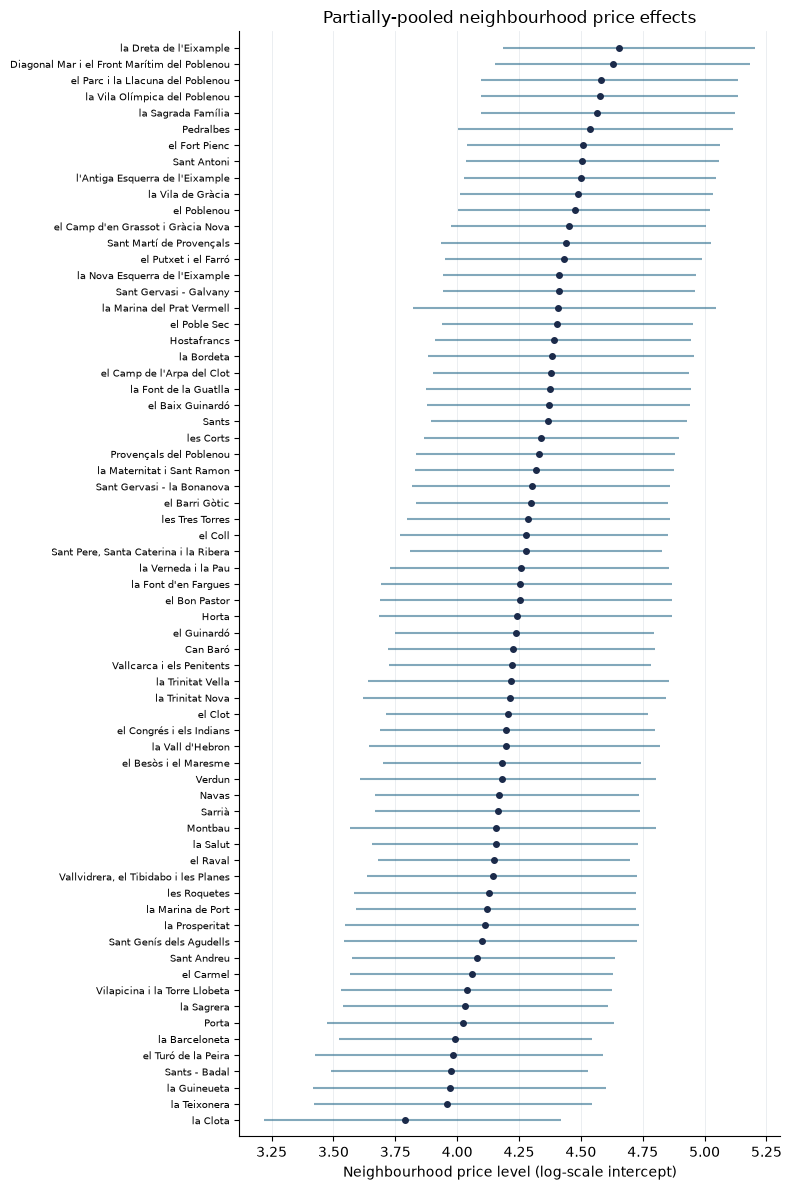

In [82]:
nbh_names = df_cleaned['neighbourhood_cleansed'].astype('category').cat.categories

a_draws = idata_hier.posterior['a'].to_numpy().reshape(-1, n_nbh)
means = a_draws.mean(axis=0)
lo = np.percentile(a_draws, 5.5, axis=0)    #89% interval (5.5 a 94.5)
hi = np.percentile(a_draws, 94.5, axis=0)

#ordered by mean (cheap -> expensive)
order = np.argsort(means)
means, lo, hi = means[order], lo[order], hi[order]
labels = np.array(nbh_names)[order]

fig, ax = plt.subplots(figsize=(8, 12))
yv = np.arange(n_nbh)
ax.hlines(yv, lo, hi, color='#2f6f8f', lw=1.5, alpha=0.6)
ax.plot(means, yv, 'o', color='#1b2a4a', ms=4)
ax.set_yticks(yv); ax.set_yticklabels(labels, fontsize=7)
ax.set_ylim(-1, n_nbh)
ax.set_xlabel('Neighbourhood price level (log-scale intercept)')
ax.set_title('Partially-pooled neighbourhood price effects')
for s in ['top','right']: ax.spines[s].set_visible(False)
ax.grid(True, axis='x', color='#e8ebef', lw=0.6)
plt.tight_layout()
plt.savefig('neighbourhood_effects.png', dpi=150, bbox_inches='tight')
plt.show()

**Key results**
- Well-calibrated prediction intervals (90% interval covers ~90% of held-out prices).
- Interpretable, sensible effects: bigger places cost more; entire homes > private > shared rooms; clear neighbourhood price gradient.
- A concrete business use: flagging potentially under-priced listings.

**Honest limitations**
- The neighbourhood boxplot earlier shows *marginal* differences; this model separates location from size and room type, but I haven't modelled interactions (e.g. luxury entire-homes specifically).
- Predictions are for *typical* listings — I trimmed the top 1% of prices, so this doesn't cover the luxury segment.
- `distance_center` turned out weak once neighbourhoods were included (they already encode location), so I left it out of the final model.

**Next steps:** try a nested hierarchy (neighbourhood within district), add interactions, and validate on a second city.

For completness lets show the prediction intervals vs actual price and the calibration curve, which shows how well calibrated is our model.

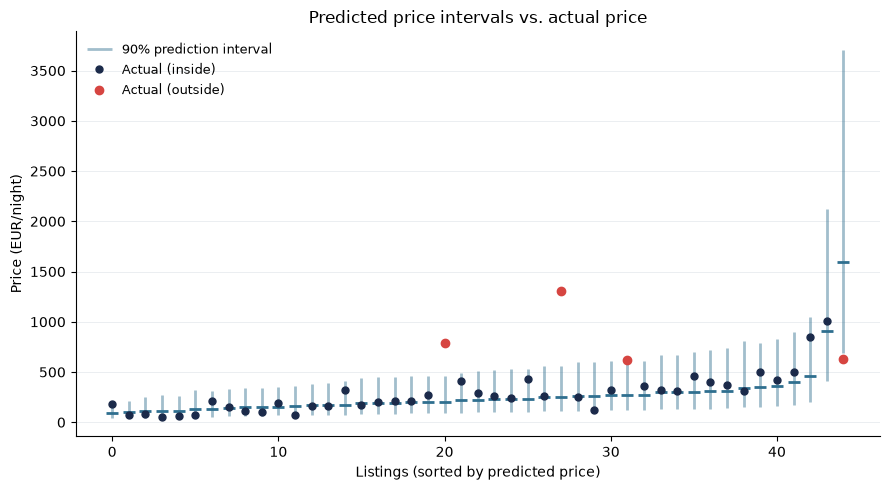

In [83]:
#Calibration plot A: prediction intervals vs actual price
#Shows that most actual prices fall inside their 90% predictive interval.
rng = np.random.default_rng(1)
sel = rng.choice(len(actual), size=45, replace=False)   #a readable subset
p_lo  = np.percentile(pred[sel], 5,  axis=1)
p_hi  = np.percentile(pred[sel], 95, axis=1)
p_med = np.percentile(pred[sel], 50, axis=1)
a_sel = actual[sel]
order = np.argsort(p_med)                                 #sort by predicted price
p_lo, p_hi, p_med, a_sel = p_lo[order], p_hi[order], p_med[order], a_sel[order]
inside = (a_sel >= p_lo) & (a_sel <= p_hi)

fig, ax = plt.subplots(figsize=(9, 5))
xv = np.arange(len(a_sel))
ax.vlines(xv, p_lo, p_hi, color='#2f6f8f', lw=2, alpha=0.45, label='90% prediction interval')
ax.plot(xv, p_med, '_', color='#2f6f8f', ms=9, mew=2)                       #median tick
ax.plot(xv[inside],  a_sel[inside],  'o', color='#1b2a4a', ms=5, label='Actual (inside)')
ax.plot(xv[~inside], a_sel[~inside], 'o', color='#d64541', ms=6, label='Actual (outside)')
ax.set_xlabel('Listings (sorted by predicted price)')
ax.set_ylabel('Price (EUR/night)')
ax.set_title('Predicted price intervals vs. actual price')
for s in ['top','right']: ax.spines[s].set_visible(False)
ax.grid(True, axis='y', color='#e8ebef', lw=0.6)
ax.legend(frameon=False, fontsize=9, loc='upper left')
plt.tight_layout()
plt.savefig('calibration_intervals.png', dpi=150, bbox_inches='tight')
plt.show()

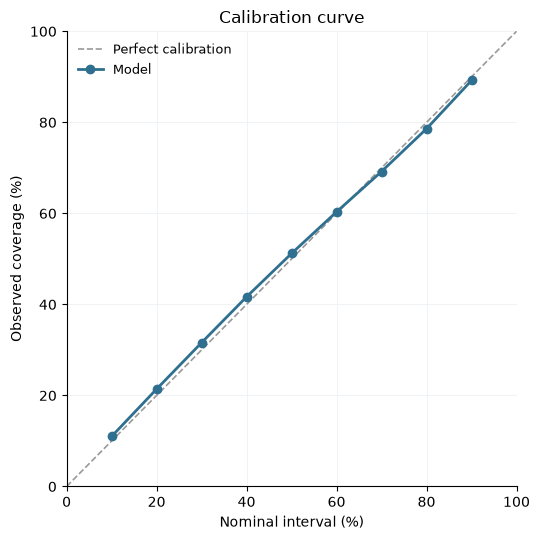

In [84]:
#Calibration plot B: observed coverage vs nominal interval, at every level.
#A well-calibrated model sits on the diagonal.
levels = np.arange(10, 100, 10)
observed = []
for lv in levels:
    lo = np.percentile(pred, (100 - lv) / 2,       axis=1)
    hi = np.percentile(pred, 100 - (100 - lv) / 2, axis=1)
    observed.append(np.mean((actual >= lo) & (actual <= hi)) * 100)

fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.plot([0, 100], [0, 100], '--', color='#999', lw=1.2, label='Perfect calibration')
ax.plot(levels, observed, 'o-', color='#2f6f8f', lw=2, ms=6, label='Model')
ax.set_xlabel('Nominal interval (%)')
ax.set_ylabel('Observed coverage (%)')
ax.set_title('Calibration curve')
ax.set_xlim(0, 100); ax.set_ylim(0, 100)
for s in ['top','right']: ax.spines[s].set_visible(False)
ax.grid(True, color='#eef1f4', lw=0.6)
ax.legend(frameon=False, fontsize=9, loc='upper left')
plt.tight_layout()
plt.savefig('calibration_curve.png', dpi=150, bbox_inches='tight')
plt.show()